# Абляционные эксперименты для модели CatBoost

В данном ноутбуке проводится сравнительный анализ нескольких вариантов набора признаков для задачи прогнозирования качества сна. 
Исследуются три постановки: полная модель, модель без прямых лагов качества сна и модель только на признаках активности и режима носимого устройства.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys

sys.path.append(str(Path("..").resolve()))

from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay
)

from catboost import CatBoostClassifier, Pool
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

from xgboost import XGBClassifier
from lightgbm import LGBMClassifier

from src.config import (
    MODEL_DATA_PATH,
    RANDOM_STATE,
    CATBOOST_MODEL_DIR,
    REPORT_TABLES_DIR,
    REPORT_TEXT_DIR,
    REPORT_LOGS_DIR,
    CM_FIG_DIR,
    FI_FIG_DIR
)

In [2]:
model_df = pd.read_csv(MODEL_DATA_PATH)

print(model_df.shape)
model_df.head()

(47523, 82)


,SEQN,calendar_date,weekday,dayofweek,window_number,night_number,month,day,dayofyear,target_bad_sleep,...,dur_spt_sleep_min_lag3,dur_spt_wake_IN_min_lag3,dur_spt_wake_LIG_min_lag3,dur_spt_wake_MOD_min_lag3,dur_spt_wake_VIG_min_lag3,dur_day_min_lag3,dur_spt_min_lag3,dur_day_spt_min_lag3,ACC_spt_sleep_mg_lag3,excluded_lag3
0,62161,2000-01-12,Wednesday,4,4,5,1,12,12,1,...,436.0,39.0,2.0,0.0,0.0,876.0,477.0,1353.0,6.743,0.0
1,62161,2000-01-13,Thursday,5,5,6,1,13,13,1,...,403.0,92.0,1.0,0.0,0.0,942.0,496.0,1438.0,3.550,0.0
2,62161,2000-01-14,Friday,6,6,7,1,14,14,1,...,435.0,101.0,10.0,0.0,0.0,896.0,546.0,1442.0,3.243,0.0
3,62161,2000-01-15,Saturday,7,7,8,1,15,15,1,...,425.0,108.0,5.0,0.0,0.0,902.0,538.0,1440.0,5.848,0.0
4,62163,2000-01-12,Wednesday,4,4,5,1,12,12,0,...,332.0,43.0,3.0,0.0,0.0,1004.0,378.0,1382.0,11.669,0.0


In [3]:
print(model_df["target_bad_sleep"].value_counts(normalize=True))

target_bad_sleep
0    0.627928
1    0.372072
Name: proportion, dtype: float64


Базовое разбиение

In [4]:
target_col = "target_bad_sleep"
group_col = "SEQN"

X = model_df.drop(columns=[target_col]).copy()
y = model_df[target_col].astype(int).copy()
groups = model_df[group_col].copy()

Зафиксируем одно разбиение по участникам

Важно: для всех трёх экспериментов используем одно и то же разбиение, чтобы сравнение было честным.

In [5]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=RANDOM_STATE)

train_idx, test_idx = next(gss.split(X, y, groups=groups))

X_train_full = X.iloc[train_idx].copy()
X_test_full = X.iloc[test_idx].copy()

y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

groups_train = groups.iloc[train_idx]
groups_test = groups.iloc[test_idx]

print("Train:", X_train_full.shape, y_train.shape)
print("Test :", X_test_full.shape, y_test.shape)
print("Train users:", groups_train.nunique())
print("Test users :", groups_test.nunique())
print("Intersection:", len(set(groups_train).intersection(set(groups_test))))

Train: (37976, 81) (37976,)
Test : (9547, 81) (9547,)
Train users: 10430
Test users : 2608
Intersection: 0


In [6]:
base_drop_cols = ["SEQN", "calendar_date"]

X_train_full = X_train_full.drop(columns=base_drop_cols)
X_test_full = X_test_full.drop(columns=base_drop_cols)

print(X_train_full.shape, X_test_full.shape)

(37976, 79) (9547, 79)


Создаем функцию выбора набора признаков

In [7]:
def select_feature_set(X: pd.DataFrame, feature_mode: str = "full") -> pd.DataFrame:
    X = X.copy()

    if feature_mode == "full":
        return X

    if feature_mode == "no_sleep_quality_lag":
        drop_cols = [
            "sleep_efficiency_lag1",
            "sleep_efficiency_lag2",
            "sleep_efficiency_lag3",
        ]
        return X.drop(columns=[c for c in drop_cols if c in X.columns])

    if feature_mode == "activity_only":
        drop_cols = [
            "sleep_efficiency_lag1", "sleep_efficiency_lag2", "sleep_efficiency_lag3",
            "dur_spt_sleep_min_lag1", "dur_spt_sleep_min_lag2", "dur_spt_sleep_min_lag3",
            "dur_spt_wake_IN_min_lag1", "dur_spt_wake_IN_min_lag2", "dur_spt_wake_IN_min_lag3",
            "dur_spt_wake_LIG_min_lag1", "dur_spt_wake_LIG_min_lag2", "dur_spt_wake_LIG_min_lag3",
            "dur_spt_wake_MOD_min_lag1", "dur_spt_wake_MOD_min_lag2", "dur_spt_wake_MOD_min_lag3",
            "dur_spt_wake_VIG_min_lag1", "dur_spt_wake_VIG_min_lag2", "dur_spt_wake_VIG_min_lag3",
            "dur_spt_min_lag1", "dur_spt_min_lag2", "dur_spt_min_lag3",
            "sleeponset_lag1", "sleeponset_lag2", "sleeponset_lag3",
            "wakeup_lag1", "wakeup_lag2", "wakeup_lag3"
        ]
        return X.drop(columns=[c for c in drop_cols if c in X.columns])

    raise ValueError(f"Unknown feature_mode: {feature_mode}")

In [8]:
for mode in ["full", "no_sleep_quality_lag", "activity_only"]:
    X_tmp = select_feature_set(X_train_full, mode)
    print(mode, "->", X_tmp.shape[1], "features")

full -> 79 features
no_sleep_quality_lag -> 76 features
activity_only -> 52 features


Создаем функцию подбора порога

In [9]:
def evaluate_thresholds(y_true, y_proba, thresholds=None):
    if thresholds is None:
        thresholds = np.arange(0.10, 0.91, 0.05)

    rows = []

    for thr in thresholds:
        y_pred_thr = (y_proba >= thr).astype(int)

        rows.append({
            "threshold": round(float(thr), 4),
            "precision": precision_score(y_true, y_pred_thr, zero_division=0),
            "recall": recall_score(y_true, y_pred_thr, zero_division=0),
            "f1": f1_score(y_true, y_pred_thr, zero_division=0)
        })

    threshold_df = pd.DataFrame(rows)
    best_row = threshold_df.loc[threshold_df["f1"].idxmax()].copy()

    return threshold_df, best_row

Главная функция эксперимента

In [10]:
def run_catboost_experiment(
    mode: str,
    X_train_base: pd.DataFrame,
    X_test_base: pd.DataFrame,
    y_train: pd.Series,
    y_test: pd.Series
):
    print(f"\n=== Running experiment: {mode} ===")

    X_train = select_feature_set(X_train_base, mode)
    X_test = select_feature_set(X_test_base, mode)

    categorical_cols = X_train.select_dtypes(include=["object"]).columns.tolist()
    cat_features = [X_train.columns.get_loc(col) for col in categorical_cols]

    train_pool = Pool(X_train, y_train, cat_features=cat_features)
    test_pool = Pool(X_test, y_test, cat_features=cat_features)

    model = CatBoostClassifier(
        iterations=500,
        depth=6,
        learning_rate=0.05,
        loss_function="Logloss",
        eval_metric="AUC",
        random_seed=RANDOM_STATE,
        verbose=100
    )

    model.fit(
        train_pool,
        eval_set=test_pool,
        use_best_model=True
    )

    y_proba = model.predict_proba(test_pool)[:, 1]
    roc_auc = roc_auc_score(y_test, y_proba)

    threshold_df, best_row = evaluate_thresholds(y_test, y_proba)
    best_threshold = float(best_row["threshold"])

    y_pred_best = (y_proba >= best_threshold).astype(int)

    precision = precision_score(y_test, y_pred_best, zero_division=0)
    recall = recall_score(y_test, y_pred_best, zero_division=0)
    f1 = f1_score(y_test, y_pred_best, zero_division=0)

    cls_report = classification_report(y_test, y_pred_best, digits=4)
    cm = confusion_matrix(y_test, y_pred_best)

    feature_importance = pd.DataFrame({
        "feature": X_train.columns,
        "importance": model.get_feature_importance()
    }).sort_values("importance", ascending=False)

    # Сохранение таблицы порогов
    threshold_df.to_csv(REPORT_TABLES_DIR / f"catboost_thresholds_{mode}.csv", index=False)

    # Сохранение importance
    feature_importance.to_csv(
        REPORT_TABLES_DIR / f"catboost_feature_importance_{mode}.csv",
        index=False
    )

    # Сохранение classification report
    with open(REPORT_TEXT_DIR / f"classification_report_catboost_{mode}.txt", "w", encoding="utf-8") as f:
        f.write(cls_report)

    # Сохранение лога
    log_text = f"""
Experiment: {mode}
Features count: {X_train.shape[1]}
Categorical columns: {categorical_cols}
Best threshold: {best_threshold:.2f}
Best iteration: {model.get_best_iteration()}
ROC-AUC: {roc_auc:.4f}
Precision: {precision:.4f}
Recall: {recall:.4f}
F1-score: {f1:.4f}
"""
    with open(REPORT_LOGS_DIR / f"run_{mode}.txt", "w", encoding="utf-8") as f:
        f.write(log_text.strip())

    # Сохранение модели
    model.save_model(CATBOOST_MODEL_DIR / f"catboost_{mode}.cbm")

    # Сохранение test predictions
    pred_df = X_test.copy()
    pred_df["y_true"] = y_test.values
    pred_df["y_proba"] = y_proba
    pred_df[f"y_pred_thr_{str(best_threshold).replace('.', '')}"] = y_pred_best
    pred_df.to_csv(REPORT_TABLES_DIR / f"catboost_test_predictions_{mode}.csv", index=False)

    # Матрица ошибок
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    fig, ax = plt.subplots(figsize=(5, 5))
    disp.plot(ax=ax)
    plt.title(f"CatBoost confusion matrix: {mode}, thr={best_threshold:.2f}")
    plt.savefig(CM_FIG_DIR / f"catboost_{mode}_confusion_matrix.png", dpi=200, bbox_inches="tight")
    plt.show()

    # График важности признаков
    top_n = min(20, len(feature_importance))
    fi_top = feature_importance.head(top_n).sort_values("importance")

    plt.figure(figsize=(10, 8))
    plt.barh(fi_top["feature"], fi_top["importance"])
    plt.title(f"Top-{top_n} feature importance: {mode}")
    plt.xlabel("Importance")
    plt.ylabel("Feature")
    plt.savefig(FI_FIG_DIR / f"catboost_{mode}_top{top_n}.png", dpi=200, bbox_inches="tight")
    plt.show()

    result_row = {
        "mode": mode,
        "features_count": X_train.shape[1],
        "best_threshold": best_threshold,
        "roc_auc": roc_auc,
        "precision": precision,
        "recall": recall,
        "f1_score": f1,
        "best_iteration": model.get_best_iteration()
    }

    print("\nResult:")
    print(pd.Series(result_row))
    print("\nClassification report:")
    print(cls_report)

    return {
        "result_row": result_row,
        "threshold_df": threshold_df,
        "feature_importance": feature_importance,
        "classification_report": cls_report
    }

Запускаем три эксперимента


=== Running experiment: full ===


0:	test: 0.7174443	best: 0.7174443 (0)	total: 259ms	remaining: 2m 9s
100:	test: 0.7443317	best: 0.7443317 (100)	total: 10.4s	remaining: 41s
200:	test: 0.7452456	best: 0.7455808 (144)	total: 20.8s	remaining: 31s
300:	test: 0.7444731	best: 0.7455808 (144)	total: 30.4s	remaining: 20.1s
400:	test: 0.7437366	best: 0.7455808 (144)	total: 40.2s	remaining: 9.91s
499:	test: 0.7430675	best: 0.7455808 (144)	total: 49.7s	remaining: 0us

bestTest = 0.7455808031
bestIteration = 144

Shrink model to first 145 iterations.


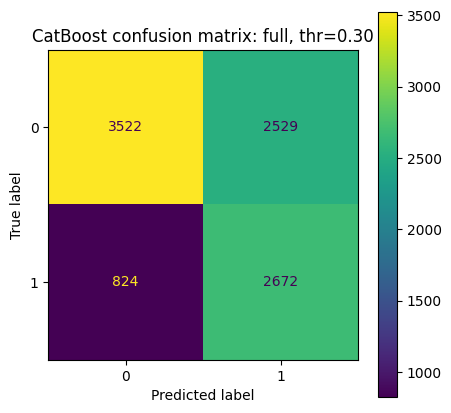

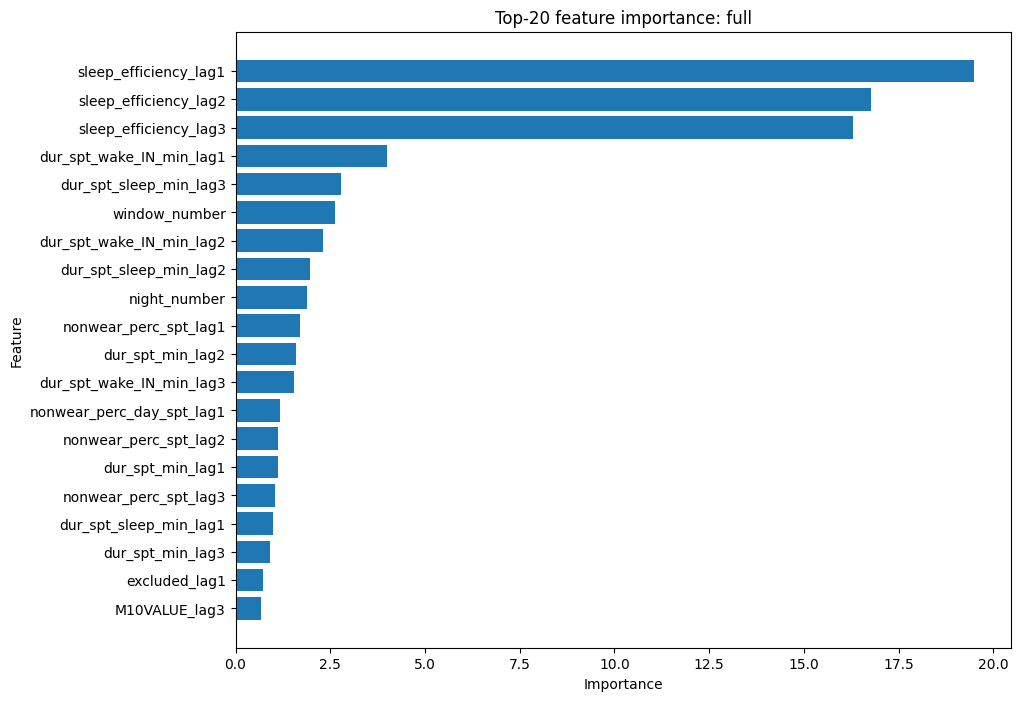


Result:
mode                  full
features_count          79
best_threshold         0.3
roc_auc           0.745581
precision         0.513747
recall            0.764302
f1_score          0.614465
best_iteration         144
dtype: object

Classification report:
              precision    recall  f1-score   support

           0     0.8104    0.5821    0.6775      6051
           1     0.5137    0.7643    0.6145      3496

    accuracy                         0.6488      9547
   macro avg     0.6621    0.6732    0.6460      9547
weighted avg     0.7018    0.6488    0.6544      9547


=== Running experiment: no_sleep_quality_lag ===
0:	test: 0.7035774	best: 0.7035774 (0)	total: 78.6ms	remaining: 39.2s
100:	test: 0.7448598	best: 0.7448998 (99)	total: 9.46s	remaining: 37.4s
200:	test: 0.7460434	best: 0.7461385 (167)	total: 18.9s	remaining: 28.1s
300:	test: 0.7459815	best: 0.7461385 (167)	total: 28.3s	remaining: 18.7s
400:	test: 0.7458599	best: 0.7461385 (167)	total: 37.7s	remaining: 9.3s


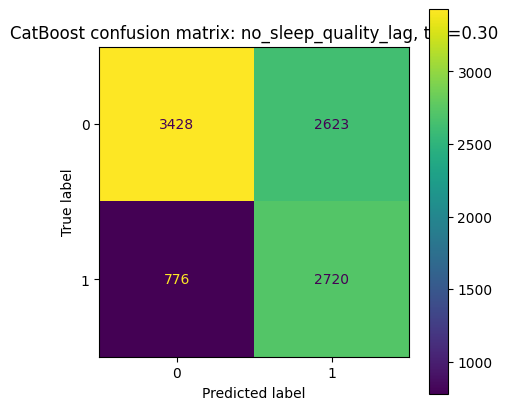

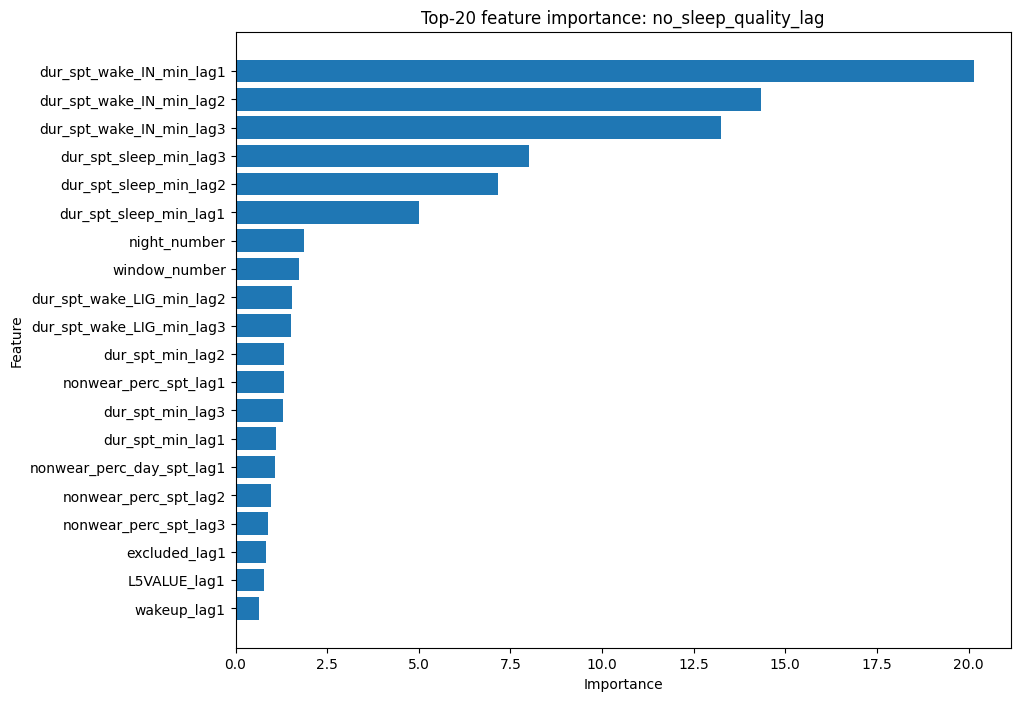


Result:
mode              no_sleep_quality_lag
features_count                      76
best_threshold                     0.3
roc_auc                       0.746139
precision                     0.509077
recall                        0.778032
f1_score                      0.615454
best_iteration                     167
dtype: object

Classification report:
              precision    recall  f1-score   support

           0     0.8154    0.5665    0.6686      6051
           1     0.5091    0.7780    0.6155      3496

    accuracy                         0.6440      9547
   macro avg     0.6622    0.6723    0.6420      9547
weighted avg     0.7032    0.6440    0.6491      9547


=== Running experiment: activity_only ===
0:	test: 0.5454592	best: 0.5454592 (0)	total: 84ms	remaining: 41.9s
100:	test: 0.5941637	best: 0.5950418 (86)	total: 9.31s	remaining: 36.8s
200:	test: 0.5987221	best: 0.5987221 (200)	total: 18.5s	remaining: 27.6s
300:	test: 0.6015843	best: 0.6017060 (299)	total: 27.8s	re

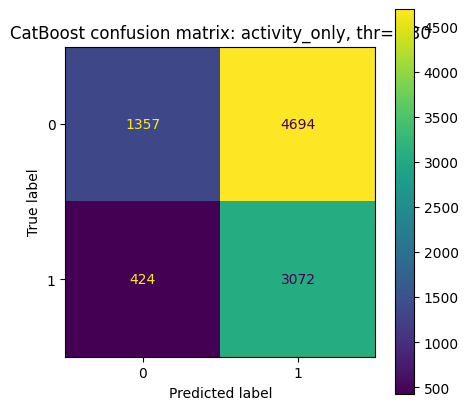

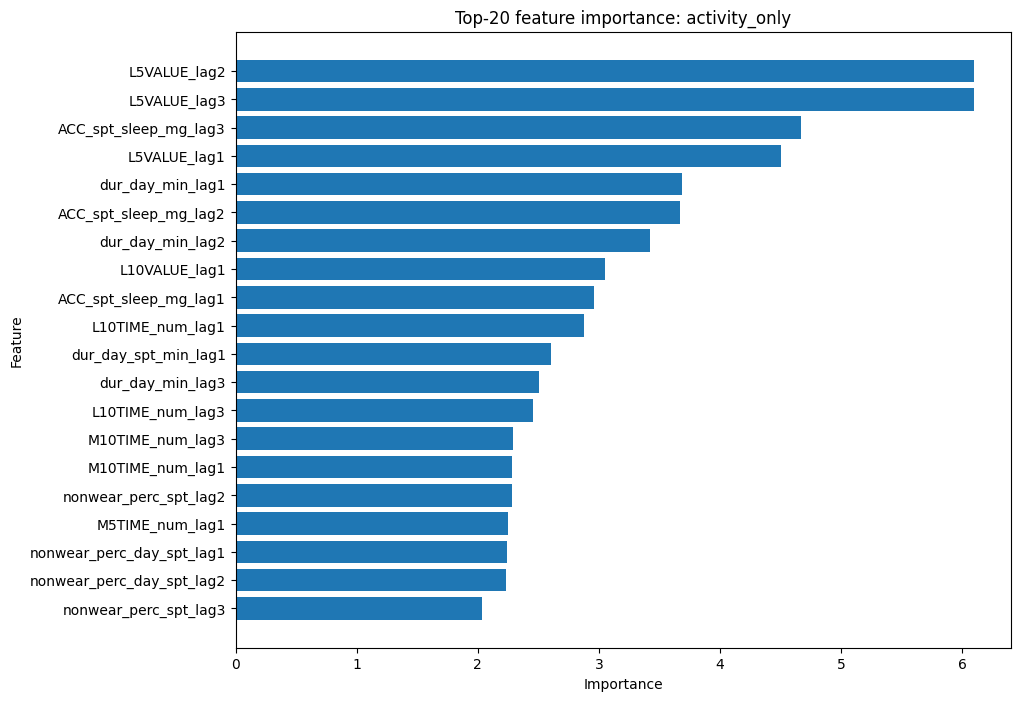


Result:
mode              activity_only
features_count               52
best_threshold              0.3
roc_auc                0.601706
precision               0.39557
recall                 0.878719
f1_score               0.545551
best_iteration              299
dtype: object

Classification report:
              precision    recall  f1-score   support

           0     0.7619    0.2243    0.3465      6051
           1     0.3956    0.8787    0.5456      3496

    accuracy                         0.4639      9547
   macro avg     0.5788    0.5515    0.4460      9547
weighted avg     0.6278    0.4639    0.4194      9547



In [11]:
results = {}

for mode in ["full", "no_sleep_quality_lag", "activity_only"]:
    results[mode] = run_catboost_experiment(
        mode=mode,
        X_train_base=X_train_full,
        X_test_base=X_test_full,
        y_train=y_train,
        y_test=y_test
    )

In [12]:
ablation_comparison = pd.DataFrame([
    results["full"]["result_row"],
    results["no_sleep_quality_lag"]["result_row"],
    results["activity_only"]["result_row"]
]).round(4)

ablation_comparison

,mode,features_count,best_threshold,roc_auc,precision,recall,f1_score,best_iteration
0,full,79,0.3,0.7456,0.5137,0.7643,0.6145,144
1,no_sleep_quality_lag,76,0.3,0.7461,0.5091,0.7780,0.6155,167
2,activity_only,52,0.3,0.6017,0.3956,0.8787,0.5456,299


In [13]:
ablation_table_for_diploma = ablation_comparison.copy()

mode_name_map = {
    "full": "Полная модель",
    "no_sleep_quality_lag": "Без прямых лагов качества сна",
    "activity_only": "Только активность и режим"
}

ablation_table_for_diploma["model_name"] = ablation_table_for_diploma["mode"].map(mode_name_map)

ablation_table_for_diploma = ablation_table_for_diploma[
    [
        "model_name",
        "features_count",
        "best_threshold",
        "roc_auc",
        "precision",
        "recall",
        "f1_score",
        "best_iteration"
    ]
]

ablation_table_for_diploma = ablation_table_for_diploma.rename(columns={
    "model_name": "Конфигурация модели",
    "features_count": "Число признаков",
    "best_threshold": "Порог",
    "roc_auc": "ROC-AUC",
    "precision": "Precision",
    "recall": "Recall",
    "f1_score": "F1",
    "best_iteration": "Лучшая итерация"
})

ablation_table_for_diploma = ablation_table_for_diploma.round(4)

ablation_table_for_diploma.to_csv(
    REPORT_TABLES_DIR / "ablation_table_for_diploma_precision_recall.csv",
    index=False
)

ablation_table_for_diploma

,Конфигурация модели,Число признаков,Порог,ROC-AUC,Precision,Recall,F1,Лучшая итерация
0,Полная модель,79,0.3,0.7456,0.5137,0.7643,0.6145,144
1,Без прямых лагов качества сна,76,0.3,0.7461,0.5091,0.7780,0.6155,167
2,Только активность и режим,52,0.3,0.6017,0.3956,0.8787,0.5456,299


In [14]:
ablation_comparison.to_csv(REPORT_TABLES_DIR / "ablation_comparison.csv", index=False)

Сравнение бустингов

In [24]:
# ============================================================
# Сравнение бустингов: CatBoost / XGBoost / LightGBM
# Используется та же схема данных, что и в абляционных экспериментах
# Основная постановка: no_sleep_quality_lag
# ============================================================

BOOSTING_FEATURE_MODE = "no_sleep_quality_lag"

print("Feature mode:", BOOSTING_FEATURE_MODE)

# Берём тот же набор признаков, что использовался в абляциях
X_train_boost = select_feature_set(X_train_full, BOOSTING_FEATURE_MODE).copy()
X_test_boost = select_feature_set(X_test_full, BOOSTING_FEATURE_MODE).copy()

print("Train shape:", X_train_boost.shape)
print("Test shape :", X_test_boost.shape)


def make_one_hot_encoder():
    """
    Совместимость с разными версиями scikit-learn:
    в новых версиях используется sparse_output,
    в старых — sparse.
    """
    try:
        return OneHotEncoder(handle_unknown="ignore", sparse_output=True)
    except TypeError:
        return OneHotEncoder(handle_unknown="ignore", sparse=True)


def prepare_sklearn_boosting_data(
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame
):
    """
    Подготовка данных для XGBoost и LightGBM.

    CatBoost умеет работать с категориальными признаками напрямую,
    а XGBoost и LightGBM в данном варианте получают:
    - числовые признаки после median-imputer;
    - категориальные признаки после OneHotEncoder.
    """

    X_train_local = X_train_input.copy()
    X_test_local = X_test_input.copy()

    categorical_cols = X_train_local.select_dtypes(
        include=["object", "category"]
    ).columns.tolist()

    numeric_cols = [
        col for col in X_train_local.columns
        if col not in categorical_cols
    ]

    # На всякий случай приводим числовые признаки к числовому типу
    for col in numeric_cols:
        X_train_local[col] = pd.to_numeric(X_train_local[col], errors="coerce")
        X_test_local[col] = pd.to_numeric(X_test_local[col], errors="coerce")

    # Категориальные признаки приводим к строкам,
    # чтобы OneHotEncoder не падал на смешанных типах
    for col in categorical_cols:
        X_train_local[col] = X_train_local[col].astype("string").fillna("missing")
        X_test_local[col] = X_test_local[col].astype("string").fillna("missing")

    numeric_transformer = Pipeline(steps=[
        ("imputer", SimpleImputer(strategy="median"))
    ])

    categorical_transformer = Pipeline(steps=[
        ("onehot", make_one_hot_encoder())
    ])

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", numeric_transformer, numeric_cols),
            ("cat", categorical_transformer, categorical_cols)
        ],
        remainder="drop"
    )

    return X_train_local, X_test_local, preprocessor, numeric_cols, categorical_cols


def evaluate_boosting_model(
    model_name: str,
    model,
    X_train_input: pd.DataFrame,
    X_test_input: pd.DataFrame,
    y_train_input: pd.Series,
    y_test_input: pd.Series
):
    """
    Обучает модель, подбирает порог по текущей логике evaluate_thresholds
    и возвращает метрики качества.
    """

    model.fit(X_train_input, y_train_input)

    y_proba = model.predict_proba(X_test_input)[:, 1]

    threshold_df, best_row = evaluate_thresholds(y_test_input, y_proba)
    best_threshold = float(best_row["threshold"])

    y_pred = (y_proba >= best_threshold).astype(int)

    result_row = {
        "model": model_name,
        "feature_mode": BOOSTING_FEATURE_MODE,
        "features_count": X_train_input.shape[1],
        "best_threshold": best_threshold,
        "roc_auc": roc_auc_score(y_test_input, y_proba),
        "precision": precision_score(y_test_input, y_pred, zero_division=0),
        "recall": recall_score(y_test_input, y_pred, zero_division=0),
        "f1_score": f1_score(y_test_input, y_pred, zero_division=0)
    }

    threshold_df.to_csv(
        REPORT_TABLES_DIR / f"thresholds_{model_name.lower()}_{BOOSTING_FEATURE_MODE}.csv",
        index=False
    )

    pred_df = pd.DataFrame({
        "y_true": y_test_input.values,
        "y_proba": y_proba,
        "y_pred": y_pred
    })

    pred_df.to_csv(
        REPORT_TABLES_DIR / f"predictions_{model_name.lower()}_{BOOSTING_FEATURE_MODE}.csv",
        index=False
    )

    print("\n", model_name)
    print("Feature mode    :", result_row["feature_mode"])
    print("Features count  :", result_row["features_count"])
    print("Best threshold  :", round(result_row["best_threshold"], 4))
    print("ROC-AUC         :", round(result_row["roc_auc"], 4))
    print("Precision       :", round(result_row["precision"], 4))
    print("Recall          :", round(result_row["recall"], 4))
    print("F1-score        :", round(result_row["f1_score"], 4))

    return result_row


# ---------- CatBoost ----------
# Для CatBoost берём уже полученный результат из абляционного эксперимента,
# чтобы не переобучать ту же модель второй раз.
catboost_row = results[BOOSTING_FEATURE_MODE]["result_row"].copy()

catboost_result = {
    "model": "CatBoost",
    "feature_mode": BOOSTING_FEATURE_MODE,
    "features_count": catboost_row["features_count"],
    "best_threshold": catboost_row["best_threshold"],
    "roc_auc": catboost_row["roc_auc"],
    "precision": catboost_row["precision"],
    "recall": catboost_row["recall"],
    "f1_score": catboost_row["f1_score"]
}


# ---------- Подготовка данных для XGBoost / LightGBM ----------
X_train_sklearn, X_test_sklearn, preprocessor, numeric_cols, categorical_cols = prepare_sklearn_boosting_data(
    X_train_boost,
    X_test_boost
)

print("\nNumeric columns:", len(numeric_cols))
print("Categorical columns:", len(categorical_cols))


# ---------- XGBoost ----------
xgb_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", XGBClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective="binary:logistic",
        eval_metric="logloss",
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

xgboost_result = evaluate_boosting_model(
    model_name="XGBoost",
    model=xgb_pipeline,
    X_train_input=X_train_sklearn,
    X_test_input=X_test_sklearn,
    y_train_input=y_train,
    y_test_input=y_test
)


# ---------- LightGBM ----------
lgbm_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", LGBMClassifier(
        n_estimators=500,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbose=-1
    ))
])

lightgbm_result = evaluate_boosting_model(
    model_name="LightGBM",
    model=lgbm_pipeline,
    X_train_input=X_train_sklearn,
    X_test_input=X_test_sklearn,
    y_train_input=y_train,
    y_test_input=y_test
)


# ---------- Итоговая таблица ----------
boosting_comparison = pd.DataFrame([
    catboost_result,
    xgboost_result,
    lightgbm_result
])

boosting_comparison = boosting_comparison.sort_values(
    ["f1_score", "roc_auc"],
    ascending=False
).reset_index(drop=True)

boosting_comparison_rounded = boosting_comparison.round(4)

boosting_comparison_rounded.to_csv(
    REPORT_TABLES_DIR / f"boosting_comparison_{BOOSTING_FEATURE_MODE}.csv",
    index=False
)

boosting_comparison_rounded

Feature mode: no_sleep_quality_lag
Train shape: (37976, 76)
Test shape : (9547, 76)

Numeric columns: 75
Categorical columns: 1

 XGBoost
Feature mode    : no_sleep_quality_lag
Features count  : 76
Best threshold  : 0.3
ROC-AUC         : 0.7427
Precision       : 0.5123
Recall          : 0.7523
F1-score        : 0.6095


c:\Users\Олег\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



 LightGBM
Feature mode    : no_sleep_quality_lag
Features count  : 76
Best threshold  : 0.3
ROC-AUC         : 0.7414
Precision       : 0.5133
Recall          : 0.7572
F1-score        : 0.6118


,model,feature_mode,features_count,best_threshold,roc_auc,precision,recall,f1_score
0,CatBoost,no_sleep_quality_lag,76,0.3,0.7461,0.5091,0.7780,0.6155
1,LightGBM,no_sleep_quality_lag,76,0.3,0.7414,0.5133,0.7572,0.6118
2,XGBoost,no_sleep_quality_lag,76,0.3,0.7427,0.5123,0.7523,0.6095


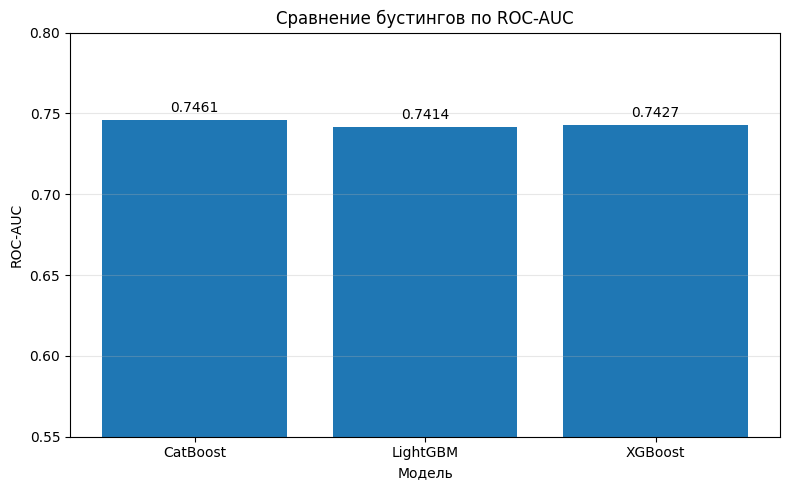

In [25]:
BOOSTING_FIG_DIR = Path("../figures/chapter3")
BOOSTING_FIG_DIR.mkdir(parents=True, exist_ok=True)

plot_df = boosting_comparison_rounded.copy()

plt.figure(figsize=(8, 5))

bars = plt.bar(
    plot_df["model"],
    plot_df["roc_auc"]
)

plt.title("Сравнение бустингов по ROC-AUC")
plt.xlabel("Модель")
plt.ylabel("ROC-AUC")
plt.ylim(0.55, 0.80)
plt.grid(axis="y", alpha=0.3)

for bar, value in zip(bars, plot_df["roc_auc"]):
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        value + 0.003,
        f"{value:.4f}",
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(
    BOOSTING_FIG_DIR / f"boosting_comparison_roc_auc_{BOOSTING_FEATURE_MODE}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

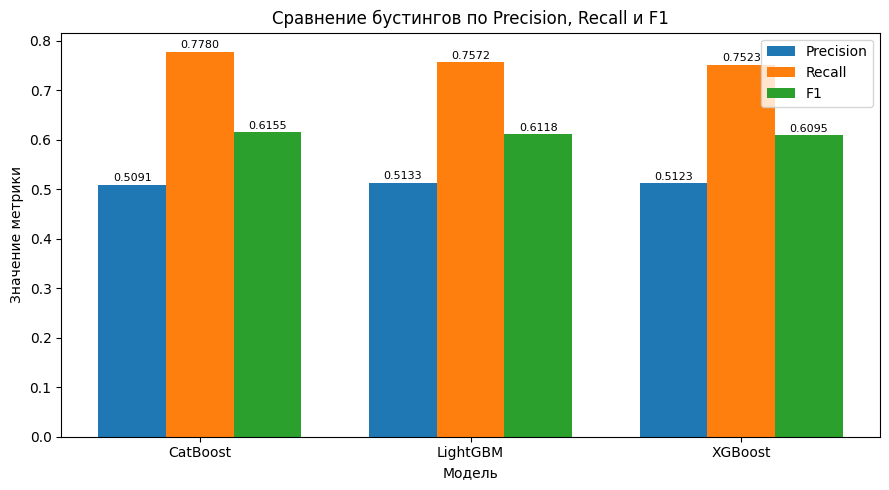

In [40]:
plot_df = boosting_comparison_rounded.copy()

metric_cols = ["precision", "recall", "f1_score"]
metric_labels = ["Precision", "Recall", "F1"]

x = np.arange(len(plot_df))
width = 0.25

plt.figure(figsize=(9, 5))

for i, (col, label) in enumerate(zip(metric_cols, metric_labels)):
    bars = plt.bar(
        x + (i - 1) * width,
        plot_df[col],
        width,
        label=label
    )

    for bar, value in zip(bars, plot_df[col]):
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            value + 0.003,
            f"{value:.4f}",
            ha="center",
            va="bottom",
            fontsize=8
        )

plt.title("Сравнение бустингов по Precision, Recall и F1")
plt.xlabel("Модель")
plt.ylabel("Значение метрики")
plt.xticks(x, plot_df["model"])
# plt.ylim(0.40, 0.75)
# plt.grid(axis="y", alpha=0.3)
plt.legend()

plt.tight_layout()
plt.savefig(
    BOOSTING_FIG_DIR / f"boosting_comparison_precision_recall_f1_{BOOSTING_FEATURE_MODE}.png",
    dpi=300,
    bbox_inches="tight"
)
plt.show()

Смотрим топ-10 признаков

In [15]:
results["full"]["feature_importance"].head(10)

,feature,importance
7,sleep_efficiency_lag1,19.479636
31,sleep_efficiency_lag2,16.773597
55,sleep_efficiency_lag3,16.295230
22,dur_spt_wake_IN_min_lag1,4.005477
69,dur_spt_sleep_min_lag3,2.777681
2,window_number,2.621247
46,dur_spt_wake_IN_min_lag2,2.320967
45,dur_spt_sleep_min_lag2,1.973158
3,night_number,1.893247
9,nonwear_perc_spt_lag1,1.699435


In [16]:
results["no_sleep_quality_lag"]["feature_importance"].head(10)

,feature,importance
21,dur_spt_wake_IN_min_lag1,20.139351
44,dur_spt_wake_IN_min_lag2,14.348875
67,dur_spt_wake_IN_min_lag3,13.248539
66,dur_spt_sleep_min_lag3,8.017435
43,dur_spt_sleep_min_lag2,7.155033
20,dur_spt_sleep_min_lag1,5.002232
3,night_number,1.867229
2,window_number,1.736422
45,dur_spt_wake_LIG_min_lag2,1.541739
68,dur_spt_wake_LIG_min_lag3,1.521707


In [17]:
results["activity_only"]["feature_importance"].head(10)

,feature,importance
25,L5VALUE_lag2,6.094780
40,L5VALUE_lag3,6.094530
50,ACC_spt_sleep_mg_lag3,4.672100
10,L5VALUE_lag1,4.505960
18,dur_day_min_lag1,3.683920
35,ACC_spt_sleep_mg_lag2,3.674228
33,dur_day_min_lag2,3.426570
14,L10VALUE_lag1,3.052577
20,ACC_spt_sleep_mg_lag1,2.957218
15,L10TIME_num_lag1,2.875041


In [19]:
X_train = select_feature_set(X_train_full, 'no_sleep_quality_lag')
X_test = select_feature_set(X_test_full, 'no_sleep_quality_lag')